In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import re
import json
import math
import glob
import torch
import base64
from io import BytesIO
import matplotlib.image as mpimg
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from PIL import Image

from prompt import time_series_to_image
from utils import view_base64_image, display_messages, collect_results, compute_metrics, interval_to_vector, plot_series_and_predictions, plot_series_and_predictions_with_timestamp

from datetime import datetime, timedelta

from anom_llm.AnoAgent import AnoAgent

In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
def find_intervals(series):
    intervals = []
    start = None

    for i, value in enumerate(series):
        # 1의 시작 지점 발견 (현재 값이 1이고, 이전에 시작 지점이 정해지지 않았을 경우)
        if value == 1 and start is None:
            start = i
        # 1의 연속 구간이 끝나는 지점: 현재 값이 0인데, 1의 구간이 진행 중인 경우
        if value == 0 and start is not None:
            intervals.append([start, i])
            start = None

    # 시퀀스가 1로 끝난 경우 마지막 구간 처리
    if start is not None:
        intervals.append([start, len(series)])
    
    return intervals

def make_eval_datasets(df):
    series = torch.tensor(df[['Data']].values)

    ano_sections = find_intervals(df.Label)
    ano_sections = torch.tensor(ano_sections).unsqueeze(0)

    return ano_sections, series

### Data Load

In [4]:
datadir = '/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/'
filename_df = pd.read_csv('/home/jovyan/project/TSB-AD/Datasets/File_List/TSB-AD-U-Eva.csv')
filename_df.file_name = filename_df.file_name.apply(lambda x: os.path.join(datadir, x))
filename_df['cate'] = filename_df.file_name.apply(lambda x:x.split('/')[-1].split('_')[1])
filename_df.info()
filename_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  350 non-null    object
 1   cate       350 non-null    object
dtypes: object(2)
memory usage: 5.6+ KB


,file_name,cate
0,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/001_NAB_id_1_Facility_tr_1007_1st_2014.csv,NAB
1,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/002_NAB_id_2_WebService_tr_1500_1st_4106.csv,NAB
2,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/005_NAB_id_5_Traffic_tr_594_1st_1645.csv,NAB
3,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/006_NAB_id_6_Traffic_tr_2579_1st_5839.csv,NAB
4,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/008_NAB_id_8_Synthetic_tr_1007_1st_2734.csv,NAB


In [5]:
filename_df['cate'].value_counts()

UCR            70
SMD            33
Exathlon       30
YAHOO          30
OPPORTUNITY    27
NAB            23
WSD            20
SVDB           18
SMAP           17
IOPS           15
TODS           13
MGAB            8
NEK             8
LTDB            8
Stock           8
MITDB           7
MSL             7
TAO             2
SED             2
Daphnet         1
SWaT            1
Power           1
CATSv2          1
Name: cate, dtype: int64

In [6]:
data_name = 'YAHOO'
llm_name = 'gpt-4o'
index_type = 'timestamp' # number, timestamp, wo-index, wo-text-seq, anomllm
use_image=True
use_deseasonality=True
max_ts_len = 2000
anomaly_ratio = 0.05

idx = 4

real_df = filename_df[filename_df.cate == data_name].copy()
real_df

,file_name,cate
263,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/551_YAHOO_id_1_Synthetic_tr_500_1st_893.csv,YAHOO
264,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/552_YAHOO_id_2_Synthetic_tr_500_1st_893.csv,YAHOO
265,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/555_YAHOO_id_5_WebService_tr_500_1st_730.csv,YAHOO
266,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/558_YAHOO_id_8_WebService_tr_500_1st_1125.csv,YAHOO
267,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/562_YAHOO_id_12_Synthetic_tr_500_1st_893.csv,YAHOO
268,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/570_YAHOO_id_20_Synthetic_tr_500_1st_658.csv,YAHOO
269,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/571_YAHOO_id_21_Synthetic_tr_500_1st_623.csv,YAHOO
270,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/579_YAHOO_id_29_WebService_tr_500_1st_1342.csv,YAHOO
271,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/603_YAHOO_id_53_Synthetic_tr_500_1st_893.csv,YAHOO
272,/home/jovyan/project/TSB-AD/Datasets/TSB-AD-U/644_YAHOO_id_94_WebService_tr_500_1st_1078.csv,YAHOO


In [7]:
paths = real_df.file_name.tolist()

dfs = []
for path in paths:
    df = pd.read_csv(path)
    print(df.shape)
    dfs.append(df)
    
eval_dataset = []
for i, df in enumerate(dfs):
    ano_sections, series = make_eval_datasets(df)
    eval_dataset.append((ano_sections, series))
    
len(dfs), len(eval_dataset)

(1421, 2)
(1421, 2)
(1680, 2)
(1427, 2)
(1421, 2)
(1421, 2)
(1421, 2)
(1680, 2)
(1421, 2)
(1435, 2)
(1680, 2)
(1680, 2)
(1440, 2)
(1421, 2)
(1680, 2)
(1421, 2)
(1680, 2)
(1427, 2)
(1421, 2)
(1420, 2)
(1680, 2)
(1424, 2)
(1680, 2)
(1421, 2)
(1680, 2)
(1421, 2)
(1680, 2)
(1421, 2)
(1421, 2)
(1424, 2)


(30, 30)

torch.Size([1, 1, 2]) torch.Size([1421, 1])
tensor([[893, 894]])


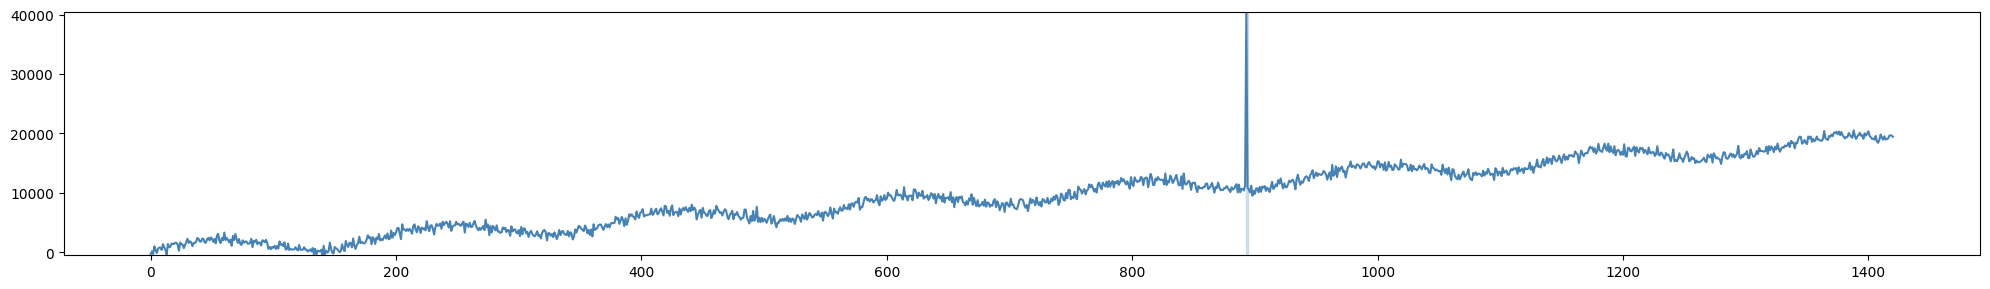

In [8]:
ano_locs, series = eval_dataset[idx]
print(ano_locs.shape, series.shape)
raw_series = series[:,0]

fig = plot_series_and_predictions(
    series=series, 
    gt_anomaly_intervals=ano_locs,
    gt_ylim = (series.min(), series.max()),
    anomalies=None, #results
)
print(ano_locs[0])

### Load Model

In [9]:
test_samples = len(eval_dataset)
model = AnoAgent(data_name=data_name, llm_model=llm_name, max_ts_len=max_ts_len, index_type=index_type, min_acf_period=24, value_scale=10)

In [10]:
st, ed = 0, 3000
pred_vector, sample_request, sample_response = model.sample_get_prompt_and_response(series[st:ed, 0], anomaly_ratio=anomaly_ratio, use_deseasonal=use_deseasonality, use_image=use_image, context=None)

2025-04-28 07:27:33.331 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


In [11]:
sample_request['messages'][0]['content'][0]

{'type': 'text',
 'text': '\nI will provide you with time-series data recorded at hourly intervals, along with a plotted time-series image.\n\nHere is time-series data in (timestamp, value) format:\n<history>\n(2024-04-01 00:00:00, 0.06)\n(2024-04-01 00:11:25, 0.12)\n(2024-04-01 00:22:51, 0.09)\n(2024-04-01 00:34:17, 0.37)\n(2024-04-01 00:45:42, 0.31)\n(2024-04-01 00:57:08, 0.13)\n(2024-04-01 01:08:34, 0.29)\n(2024-04-01 01:20:00, 0.37)\n(2024-04-01 01:31:25, 0.39)\n(2024-04-01 01:42:51, 0.21)\n(2024-04-01 01:54:17, 0.51)\n(2024-04-01 02:05:42, -0.42)\n(2024-04-01 02:17:08, 0.19)\n(2024-04-01 02:28:34, 0.07)\n(2024-04-01 02:40:00, 0.47)\n(2024-04-01 02:51:25, 0.34)\n(2024-04-01 03:02:51, 0.42)\n(2024-04-01 03:14:17, 0.55)\n(2024-04-01 03:25:42, 0.53)\n(2024-04-01 03:37:08, 0.50)\n(2024-04-01 03:48:34, 0.55)\n(2024-04-01 04:00:00, 0.53)\n(2024-04-01 04:11:25, 0.41)\n(2024-04-01 04:22:51, 0.17)\n(2024-04-01 04:34:17, 0.57)\n(2024-04-01 04:45:42, 0.49)\n(2024-04-01 04:57:08, 0.50)\n(2024-

In [12]:
sample_request.keys(), sample_request['messages'][0].keys(), sample_response

(dict_keys(['messages', 'temperature', 'stop']),
 dict_keys(['role', 'content']),
 '```json\n[{"start timestamp": "2024-04-08 02:05:42", "end timestamp": "2024-04-08 02:05:42"}]\n```')

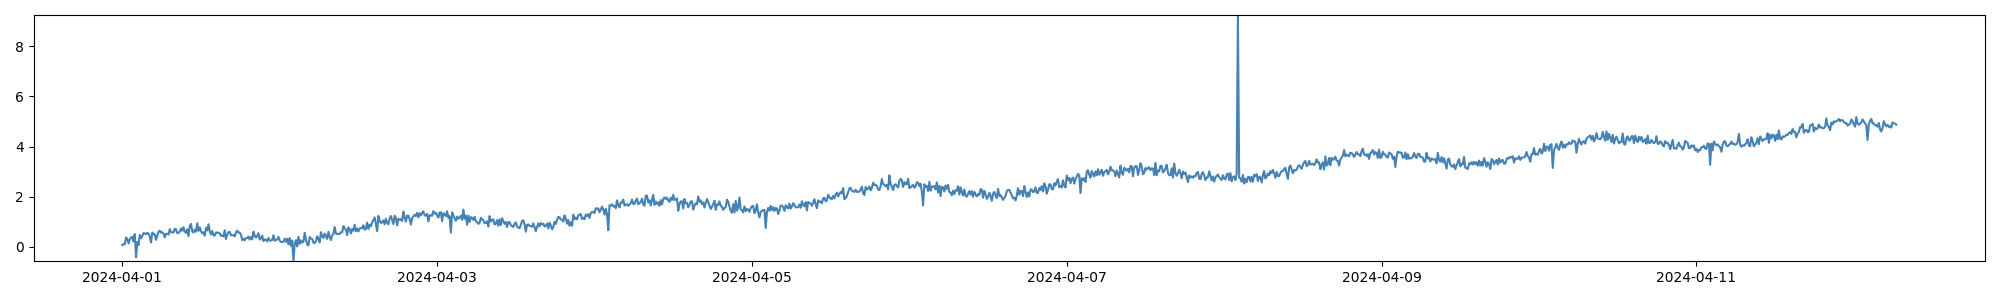

In [13]:
if use_image:
    base64_str = sample_request['messages'][0]['content'][1]['image_url']['url'].split(',')[1]
    img_data = base64.b64decode(base64_str)
    img = Image.open(BytesIO(img_data))
    img.show()

In [14]:
pred_vector = pred_vector.reshape(-1, 1)
pred_vector.shape

(1421, 1)

In [15]:
pred_vector = model.inference(series[:, 0], anomaly_ratio=anomaly_ratio, use_deseasonal=use_deseasonality, use_image=use_image, context=None)
pred_vector = pred_vector.reshape(-1, 1)
pred_vector.shape

2025-04-28 07:27:36.838 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


(1421, 1)

In [16]:
gt = interval_to_vector(ano_locs.numpy()[0], end=pred_vector.shape[0])
our_metrics = compute_metrics(gt, pred_vector.astype(bool).astype(int))
our_metrics

{'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'affi precision': 1.0,
 'affi recall': 1.0,
 'affi f1': 1.0}

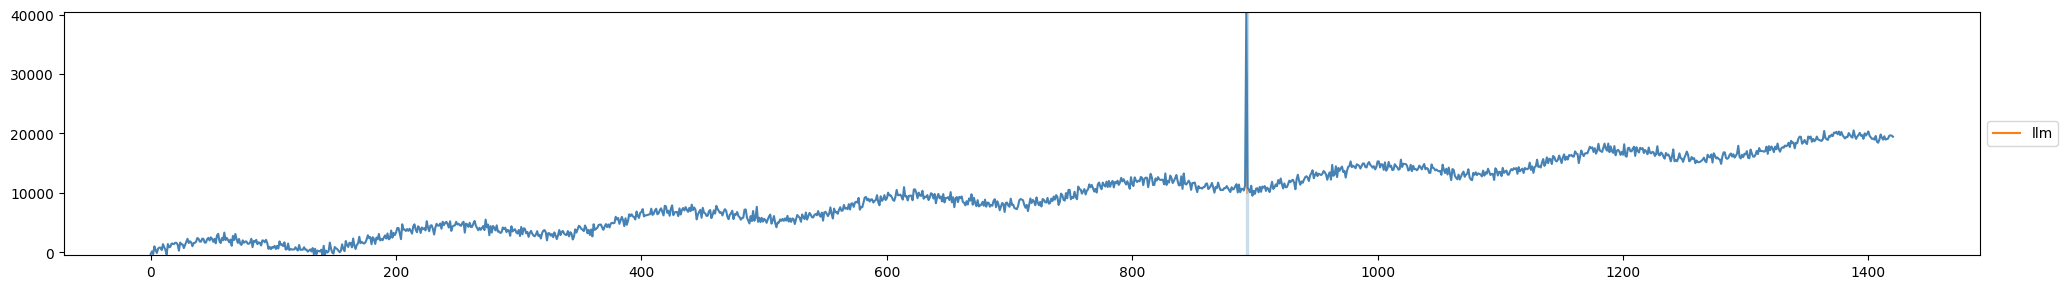

In [17]:
pred_loc = {'llm': pred_vector} 
fig = plot_series_and_predictions(
    series=series, 
    gt_anomaly_intervals=ano_locs,
    gt_ylim = (series.min(), series.max()),
    anomalies=pred_loc,
)

In [18]:
raise Exception()

Exception: 

### For all data

In [19]:
jsonl_filename = f"./results/{data_name}_{llm_name}_itype-{index_type}_ar{int(anomaly_ratio*1000)}_maxlen{max_ts_len}_ts{test_samples}.jsonl2"
if os.path.exists(jsonl_filename):
    with open(jsonl_filename, "w", encoding="utf-8") as f:
        f.write("")
print(jsonl_filename)

./results/YAHOO_gpt-4o_itype-timestamp_ar50_maxlen2000_ts30.jsonl2


In [20]:
def average_dict_values(dict_list):
    sums = {}
    counts = {}

    for d in dict_list:
        for key, value in d.items():
            sums[key] = sums.get(key, 0) + value
            counts[key] = counts.get(key, 0) + 1
            
    # 각 키에 대해 평균 계산: 합계 / 등장횟수
    averages = {key: sums[key] / counts[key] for key in sums}
    return averages

In [21]:
all_metrics = []
for i, (ano_locs, series) in enumerate(eval_dataset):
    
    st_time = time.time()
    pred_vector = model.inference(series[:, 0], anomaly_ratio=anomaly_ratio, use_deseasonal=use_deseasonality, use_image=use_image, context=None)
    pred_vector = pred_vector.reshape(-1, 1)
    inference_time = time.time() - st_time
    
    gt = interval_to_vector(ano_locs.numpy()[0], end=pred_vector.shape[0])
    our_metrics = compute_metrics(gt, pred_vector.astype(bool).astype(int))
    print(our_metrics)
    all_metrics.append(our_metrics)
    
    result_entry = {
        "eval_idx": i,
        "pred": pred_vector.reshape(-1).tolist(),
        "metric": our_metrics,
        "inference_time": inference_time,
    }
    
    with open(jsonl_filename, "a", encoding="utf-8") as jsonl_file:
        jsonl_file.write(json.dumps(result_entry, ensure_ascii=False) + "\n")

2025-04-28 07:28:59.767 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-04-28 07:29:06.092 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


{'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'affi precision': 1.0, 'affi recall': 1.0, 'affi f1': 1.0}


2025-04-28 07:29:09.735 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


{'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'affi precision': 1.0, 'affi recall': 1.0, 'affi f1': 1.0}


2025-04-28 07:29:17.838 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


...

{'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'affi precision': 0.999, 'affi recall': 0.999, 'affi f1': 0.999}


2025-04-28 07:33:31.670 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


{'precision': 0, 'recall': 0, 'f1': 0, 'affi precision': 0, 'affi recall': 0, 'affi f1': 0}


2025-04-28 07:33:35.260 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


{'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'affi precision': 1.0, 'affi recall': 1.0, 'affi f1': 1.0}
{'precision': 0.41, 'recall': 0.941, 'f1': 0.571, 'affi precision': 0.803, 'affi recall': 0.996, 'affi f1': 0.889}


In [22]:
aa = average_dict_values(all_metrics)
log_str = []
for k, v in aa.items():
    print(v)
    log_str.append(f'{v:.4f}')
print('\t'.join(log_str))

0.6578
0.7924
0.6774666666666669
0.8318333333333334
0.8910999999999999
0.8489666666666668
0.6578	0.7924	0.6775	0.8318	0.8911	0.8490
